# P6 — Generator retrain on `attribute_spec_text` (the real two-stage gate)

Open in Cursor, connect to a GPU (**A100 recommended** — this is a full 2-epoch train over the whole corpus; a T4 works but is slow), then **Run All**. It retrains the QLoRA generator with the **locked knobs unchanged**, swapping ONLY the input field `instruction → attribute_spec_text` (ground-truth spec, derived from each row's `measured_behavior` / refuse kind — no interpreter needed), then scores the **same P1 unit-aware holdout** with the same input.

This is the un-confounded version of the oracle gate: a **spec-aware** generator scored apples-to-apples against the one-stage baseline.

**Paste back**: the final `METRIC=<float>` line **and** the `{"bridge_summary": {…}}` line (it carries the adapter HF path + train summary).

**Gate**: two-stage is validated iff the honest token accuracy **≥ 0.362** (the one-stage baseline on the same holdout) within CI. The seam-injectivity analysis put the ceiling at 100%, so there is ample headroom.

Case trap: code at `/content/SLM` (UPPERCASE); staged corpus + `SLM_ARTIFACT_ROOT=/content/slm` (lowercase). HF upload uses the **write** token (`SLM_Alpha_Write`); read-only `HF_TOKEN` 403s.

In [1]:
## CELL 1 — provision the runtime (idempotent; run first)
import os, pathlib, subprocess, sys

REPO = '/content/SLM'
BRANCH = 'feat/two-stage'
if not pathlib.Path(REPO, '.git').is_dir():
    subprocess.run(['git', 'clone', 'https://github.com/ericrcwu001/SLM', REPO], check=True)
os.chdir(REPO)
if not os.environ.get('SLM_PROVISIONED'):
    subprocess.run(['git', 'fetch', 'origin', BRANCH], check=True)
    subprocess.run(['git', 'checkout', BRANCH], check=True)
    subprocess.run(['git', 'pull', 'origin', BRANCH], check=True)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-e', '.[sft]'], check=True)
    os.environ['SLM_PROVISIONED'] = '1'
print('HEAD:', subprocess.run(['git', 'log', '--oneline', '-1'], capture_output=True, text=True).stdout.strip())

# HF read + write tokens (write is needed to upload the retrained adapter). Prefer an uploaded .env.
def _env_token(name):
    for _p in ('/content/SLM/.env', '/content/.env', '.env'):
        fp = pathlib.Path(_p)
        if fp.is_file():
            for _l in fp.read_text().splitlines():
                s = _l.strip()
                if s.startswith(name + '='):
                    return s.split('=', 1)[1].strip().strip('"').strip("'")
    return None
import getpass
for _name, _prompt in (('HF_TOKEN', 'HF_TOKEN (read, for staging): '),
                       ('HF_WRITE_TOKEN', 'HF_WRITE_TOKEN (SLM_Alpha_Write, for adapter upload): ')):
    if not os.environ.get(_name):
        os.environ[_name] = _env_token(_name) or getpass.getpass(_prompt).strip()
print('HF_TOKEN set:', bool(os.environ.get('HF_TOKEN')), '| HF_WRITE_TOKEN set:', bool(os.environ.get('HF_WRITE_TOKEN')))

# stage the corpus ONLY if missing (~9.85GB).
os.environ['SLM_ARTIFACT_ROOT'] = '/content/slm'
if not pathlib.Path('/content/slm/tokenizer/final/model.pt').is_file():
    print('corpus missing -> staging ~9.85GB from hf://datasets/ericrcwu/LUT_SLM ...')
    subprocess.run(['slm_stage', 'stage', '--durable-root', 'hf://datasets/ericrcwu/LUT_SLM',
                    '--local-root', '/content/slm'], check=True)
else:
    print('corpus already staged at /content/slm')

HEAD: 5406d5e Add HF-corpus verification tool + exclude junk from staging packs
HF_TOKEN set: True | HF_WRITE_TOKEN set: True
corpus already staged at /content/slm


In [2]:
## CELL 2 — imports + asserts + build/reuse base_resized
import os, pathlib, shutil, json, subprocess, sys
import torch
import bitsandbytes as bnb, peft, accelerate, qwen_vl_utils
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
os.environ['SLM_ARTIFACT_ROOT'] = '/content/slm'
assert torch.cuda.is_available(), 'no CUDA — connect an A100 (recommended) or T4'
print('GPU:', torch.cuda.get_device_name(0), '| bf16:', torch.cuda.is_bf16_supported())
assert pathlib.Path('/content/slm/tokenizer/final/model.pt').is_file(), 'frozen tokenizer missing (run CELL 1)'
free_gb = shutil.disk_usage('/content').free / 1e9
need_gb = 25 if not pathlib.Path('models/base_resized/vocab_resize_manifest.json').is_file() else 5
assert free_gb > need_gb, f'need >{need_gb}GB free on /content (have {free_gb:.1f})'

D = pathlib.Path('models/base_resized')
if (D / 'vocab_resize_manifest.json').is_file() and (D / 'preprocessor_config.json').is_file():
    print('base_resized already built -> reusing.')
else:
    subprocess.run([sys.executable, '-m', 'sft.vocab_resize', '--out', 'models/base_resized'],
                   check=True, env={**os.environ, 'SLM_ARTIFACT_ROOT': '/content/slm'})
m = json.load(open(D / 'vocab_resize_manifest.json'))
assert m.get('tokenizer_version') == 'vq_v2_srgbres_17to4_cb256_t64__w91cffdd2c82f', m.get('tokenizer_version')
assert m.get('vq_codebook_sha256'), 'null vq_codebook_sha256 — identity did not bind'
print('base_resized OK; identity bound:', m['tokenizer_version'], '| free GB:', round(free_gb, 1))

GPU: NVIDIA A100-SXM4-40GB | bf16: True
base_resized OK; identity bound: vq_v2_srgbres_17to4_cb256_t64__w91cffdd2c82f | free GB: 191.1


In [3]:
## CELL 3 — verify the P2 portable-path fix landed on the freshly-staged corpus (early, non-fatal)
import os
os.environ['SLM_ARTIFACT_ROOT'] = '/content/slm'
from sft.example import resolve_image, load_rows
rows = load_rows('data/active_sft/active_rows.jsonl')            # the git (fixed) copy in the repo clone
unsup = [r for r in rows if not r.get('is_supported') and r.get('image_path')]
abs_paths = sum(1 for r in unsup if os.path.isabs(r['image_path']))
missing = [r['image_path'] for r in unsup if not os.path.exists(resolve_image(r['image_path']))]
bv2 = sum(1 for r in rows if (r.get('measured_behavior') or {}).get('behavior_vector_version') == 'behavior_v2')
print(f"[verify] unsupported rows={len(unsup)} | absolute paths={abs_paths} (want 0) | "
      f"MISSING images on staged corpus={len(missing)} (want 0)")
print(f"[verify] behavior_v2 rows={bv2} (want 2761)  <- confirms the fixed active_rows came via git")
if missing:
    print("[verify] first missing:", missing[:5])
    print("[verify] -> those refuse rows will be SKIPPED in training; paste this back so I add the "
          "missing images to the HF corpus (needs the write token).")
else:
    print("[verify] OK: portable paths resolve on the staged corpus; the refuse path will train (P2).")

[verify] unsupported rows=272 | absolute paths=0 (want 0) | MISSING images on staged corpus=0 (want 0)
[verify] behavior_v2 rows=2761 (want 2761)  <- confirms the fixed active_rows came via git
[verify] OK: portable paths resolve on the staged corpus; the refuse path will train (P2).


In [4]:
## CELL 4 — retrain the generator on attribute_spec_text + score the P1 holdout 🛑 paste back METRIC= + bridge_summary
# Locked knobs unchanged; the ONLY change is input_field=attribute_spec_text (configs/candidate_two_stage.json).
# --smoke-size 0 = full corpus (2 epochs); --score-limit 0 = full unit-aware holdout; uploads the adapter to HF.
import os
os.environ['PUSH_HF_REPO'] = 'ericrcwu/LUT_SLM_sft_adapters'
!SLM_ARTIFACT_ROOT=/content/slm PUSH_HF_REPO=$PUSH_HF_REPO python -m sft.bilevel_bridge --mode colab \
    --config /content/SLM/configs/candidate_two_stage.json --resized-model models/base_resized \
    --smoke-size 0 --score-limit 0 --timeout 28800 --run-id p6_twostage
# Compare the printed METRIC= (honest two-stage token accuracy on the P1 holdout) to the one-stage
# baseline 0.362. Two-stage validated iff METRIC >= 0.362 within CI (see score_summary in the log).


Loading weights:   0%|          | 1/824 [00:00<03:23,  4.05it/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)

Loading weights: 100%|██████████| 824/824 [00:03<00:00, 223.46it/s]
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1348: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting i

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

using image: /content/slm/luts/raw/ppr10k/global/990_6/before.jpg


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


normal warm punchy -> 64 codes, rendered
normal cool matte -> 64 codes, rendered
wacky neon orange -> 64 codes, rendered
wacky teal-orange -> 64 codes, rendered
wacky flat matte -> 64 codes, rendered
refuse out of gamut -> REFUSED


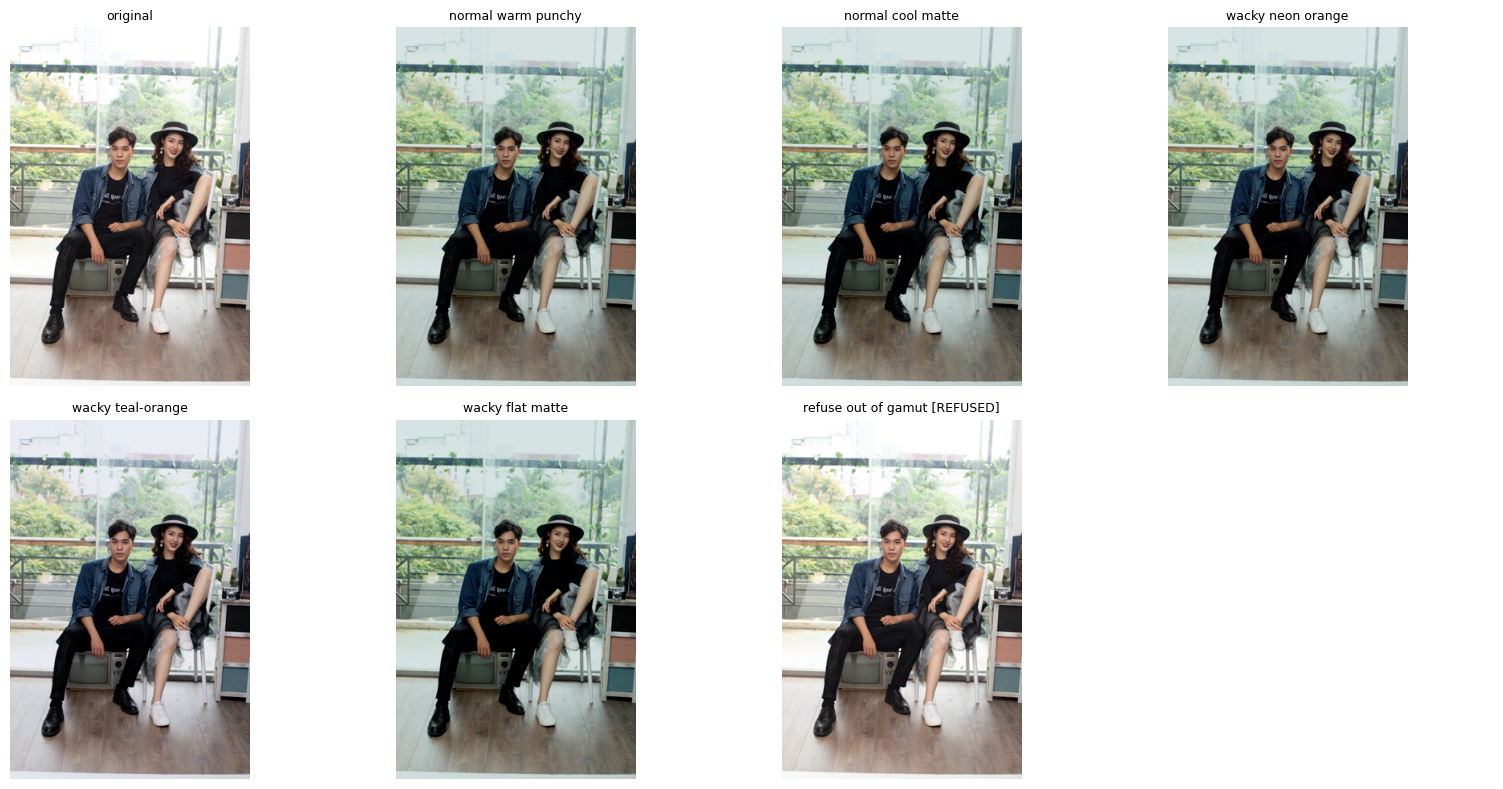

In [5]:
# P6 two-stage: upload an image, CONSTRAINED-decode each spec's LUT, render a grid.
import os, numpy as np, torch
os.environ['SLM_ARTIFACT_ROOT'] = '/content/slm'
os.chdir('/content/SLM')
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoProcessor, BitsAndBytesConfig, Qwen2_5_VLForConditionalGeneration
from peft import PeftModel
from qwen_vl_utils import process_vision_info
from sft.config import SFTConfig
from sft.example import resolve_image
from tokenizer.frozen import load_frozen_vqvae
from eval.cube_io import residual_to_absolute
from data_pipeline.lut_ops import apply_lut_trilinear
from eval.color_pipeline import to_canonical_srgb

RESIZED = 'models/base_resized'
ADAPTER = 'models/sft_adapters/p6_twostage_d0f9c744_smokefull'
SPECS = [
    ("normal warm punchy",  "route=grade | warmer=+3.0 more_contrast=+2.0"),
    ("normal cool matte",   "route=grade | cooler=+2.5 muted=+3.0 lifted_blacks=+2.0"),
    ("wacky neon orange",   "route=grade | warmer=+8.0 more_saturated=+10.0 global_hue=45 sat_orange=+8.0"),
    ("wacky teal-orange",   "route=grade | shadow_hue=210 highlight_hue=30 split_strength=12.0 more_saturated=+6.0"),
    ("wacky flat matte",    "route=grade | muted=+9.0 matte=+12.0 lifted_blacks=+9.0 less_contrast=+10.0"),
    ("refuse out of gamut", "route=refuse | refuse=out_of_gamut"),
]

cfg = SFTConfig()
dt = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type='nf4',
                         bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=dt)
proc = AutoProcessor.from_pretrained(RESIZED, trust_remote_code=True,
                                     min_pixels=cfg.min_pixels, max_pixels=cfg.max_pixels)
base = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    RESIZED, quantization_config=bnb, torch_dtype=dt, device_map='auto', trust_remote_code=True)
gen = PeftModel.from_pretrained(base, ADAPTER).eval()
vqvae, _ = load_frozen_vqvae()

tk = proc.tokenizer
BOS = tk.convert_tokens_to_ids('<lut_bos>')
LEOS = tk.convert_tokens_to_ids('<lut_eos>')
UNSUP = tk.convert_tokens_to_ids('<unsupported>')
MEOS = tk.eos_token_id
CODES = [tk.convert_tokens_to_ids('<lut_%03d>' % i) for i in range(256)]
ID2IDX = {cid: i for i, cid in enumerate(CODES)}

IMG = ''   # <-- a URL 'https://...', OR a path on the VM '/content/pic.jpg', OR '' for a corpus image
if IMG.startswith('http'):
    import urllib.request
    img_path = '/content/_demo_input.jpg'
    urllib.request.urlretrieve(IMG, img_path)
elif IMG:
    img_path = IMG
else:
    img_path = resolve_image('luts/raw/ppr10k/global/990_6/before.jpg')
print('using image:', img_path)

pil = Image.open(img_path).convert('RGB')
pil.thumbnail((448, 448))
srgb = to_canonical_srgb(np.asarray(pil))
H, W, _ = srgb.shape
flat = srgb.reshape(-1, 3)

def run_spec(spec):
    user = {"role": "user", "content": [{"type": "image", "image": img_path},
                                        {"type": "text", "text": spec}]}
    text = proc.apply_chat_template([user], tokenize=False, add_generation_prompt=True)
    imgs, vids = process_vision_info([user])
    inp = proc(text=[text], images=imgs, videos=vids, return_tensors='pt').to(gen.device)
    plen = inp['input_ids'].shape[1]
    def prefix_fn(_bid, ids):
        g = ids[plen:].tolist()
        if not g:
            return [BOS, UNSUP]
        if g[0] == UNSUP:
            return [MEOS]
        n = len(g) - 1
        if n < 64:
            return CODES
        if n == 64:
            return [LEOS]
        return [MEOS]
    with torch.no_grad():
        out = gen.generate(**inp, max_new_tokens=68, do_sample=False, num_beams=1,
                           prefix_allowed_tokens_fn=prefix_fn)
    g = out[0][plen:].tolist()
    if UNSUP in g:
        return None
    return [ID2IDX[t] for t in g if t in ID2IDX][:64]

panels = [("original", srgb)]
for label, spec in SPECS:
    codes = run_spec(spec)
    if codes is None:
        panels.append((label + " [REFUSED]", srgb))
        print(label, "-> REFUSED")
    elif len(codes) == 64:
        lut = np.clip(residual_to_absolute(vqvae.decode(codes)), 0.0, 1.0)
        graded = np.clip(apply_lut_trilinear(lut, flat), 0.0, 1.0).reshape(H, W, 3)
        panels.append((label, graded))
        print(label, "-> 64 codes, rendered")
    else:
        panels.append((label + " [invalid]", srgb))
        print(label, "-> invalid, codes:", len(codes))

cols = 4
rows = (len(panels) + cols - 1) // cols
fig, ax = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = ax.ravel()
for a, (t, im) in zip(axes, panels):
    a.imshow(im); a.set_title(t, fontsize=9); a.axis('off')
for a in axes[len(panels):]:
    a.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
# CELL 6 — Phase 0 diagnostic: does the model COLLAPSE free-running, or is there signal underneath?
# Teacher-forced token accuracy is blind to this. Here we drive the trained adapter FREE-RUNNING
# (greedy vs sampling) on a real HOLDOUT row (its ground-truth spec + image, fully in-distribution),
# and print residual RMS + the code histogram. Reuses `gen`, `proc`, `vqvae` loaded in CELL 5.
import json, numpy as np
from collections import Counter
from sft.example import resolve_image
from sft.generate import generate_codes
from sft.holdout import is_holdout_row
from data_pipeline.attribute_spec import ground_truth_attribute_spec_text

# Pick the STRONGEST holdout supported row (biggest target residual) so the collapse is obvious.
cands = []
for line in open('data/active_sft/active_rows.jsonl'):
    r = json.loads(line)
    if (r.get('is_supported') and isinstance(r.get('target_tokens'), list)
            and len(r['target_tokens']) == 64 and r.get('measured_behavior') and is_holdout_row(r)):
        cands.append(r)
        if len(cands) >= 200:
            break
assert cands, 'no holdout supported rows found'
row = max(cands, key=lambda r: float(np.sqrt((vqvae.decode(r['target_tokens'])**2).mean())))
spec = ground_truth_attribute_spec_text(row)     # two-stage conditioning (matches this adapter)
img = resolve_image(row['image_path'])
print('holdout row:', row.get('id'), '\nspec:', spec, '\nimage:', img)

def report(label, **samp):
    codes = generate_codes(gen, proc, image=img, text=spec, sampling=(samp or None), device=gen.device)
    if codes is None:
        print(f'  {label}: REFUSED'); return
    if len(codes) != 64:
        print(f'  {label}: non-64 ({len(codes)})'); return
    rms = float(np.sqrt((vqvae.decode(codes)**2).mean()))
    print(f'  {label}: RMS={rms:.4f}  top codes={Counter(codes).most_common(4)}')

ref_rms = float(np.sqrt((vqvae.decode(row['target_tokens'])**2).mean()))
print(f"\nreference (corpus target codes): RMS={ref_rms:.4f}  top={Counter(row['target_tokens']).most_common(4)}")
print('GREEDY:');       report('greedy')
print('SAMPLE t=0.7:'); report('sample', temperature=0.7, top_p=0.9)
print('SAMPLE t=1.0:'); report('sample', temperature=1.0, top_p=0.95)
print('\nRead: greedy RMS ~0.001 + one dominant code => collapse (exposure bias).')
print('      sampling RMS ~0.05-0.2 with varied codes => usable signal underneath => incremental fixes.')
print('      sampling ALSO ~0.001 => little signal => escalate to the structural pivot (Phase 4).')
